In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Настройка единого стиля графиков для портфолио
sns.set(style="whitegrid")

# ==========================================
# БЛОК 1: ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ
# ==========================================
df_logs = pd.read_csv('logs.csv')
df_users = pd.read_csv('user_data.csv')

# Объединяем логи и данные пользователей
df_game = df_logs.merge(df_users, on='client', how='inner')

print("Проверка на пустые значения:")
print(df_game.isna().sum())

# Переводим Unix-время в удобный формат datetime сразу
df_game['date_time'] = pd.to_datetime(df_game['time'], unit='s')
df_game['hour'] = df_game['date_time'].dt.hour
df_game['weekday'] = df_game['date_time'].dt.day_name()


Проверка на пустые значения:
client      0
success     0
platform    0
time        0
premium     0
age         0
dtype: int64



Самая популярная платформа среди премиум-клиентов: phone


/var/folders/fy/hf0v9l_j1mn907s1ztzmwcp00000gp/T/ipykernel_78777/1563208821.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_game.query('premium == True'), x='platform', palette='viridis')


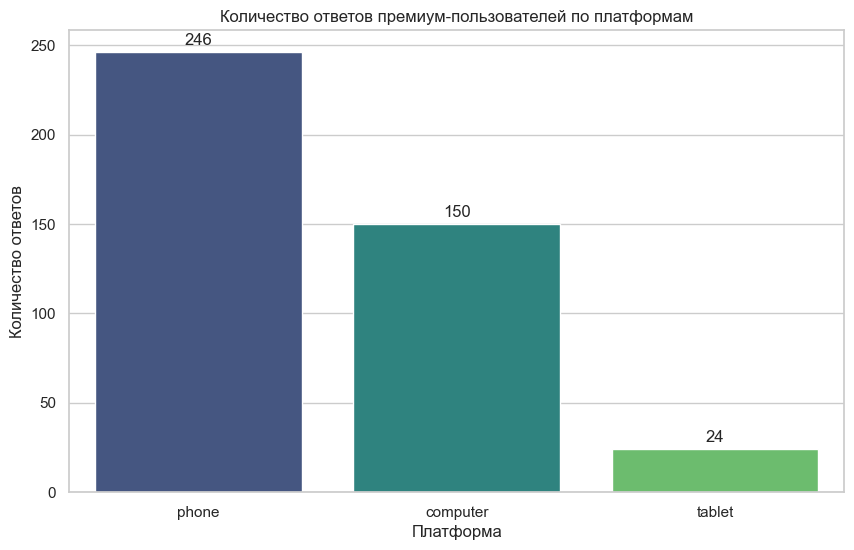


Доля успешных (True) и неуспешных (False) ответов в %:
success  False  True 
premium              
False    25.67  74.33
True     27.86  72.14


In [2]:
# ==========================================
# БЛОК 2: АНАЛИТИКА ПРЕМИУМ-СЕГМЕНТА
# ==========================================
# 2.1 Поиск самой популярной платформы среди премиум-клиентов
top_premium_platform = df_game.query('premium == True')['platform'].value_counts().idxmax()
print(f"\nСамая популярная платформа среди премиум-клиентов: {top_premium_platform}")

# 2.2 График: Количество ответов премиум-пользователей по платформам
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_game.query('premium == True'), x='platform', palette='viridis')
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Количество ответов премиум-пользователей по платформам')
plt.xlabel('Платформа')
plt.ylabel('Количество ответов')
plt.show()

# 2.3 Доля успешных ответов (Win Rate): Premium vs Free
success_rates = round(pd.crosstab(df_game['premium'], df_game['success'], normalize='index') * 100, 2)
print("\nДоля успешных (True) и неуспешных (False) ответов в %:")
print(success_rates)

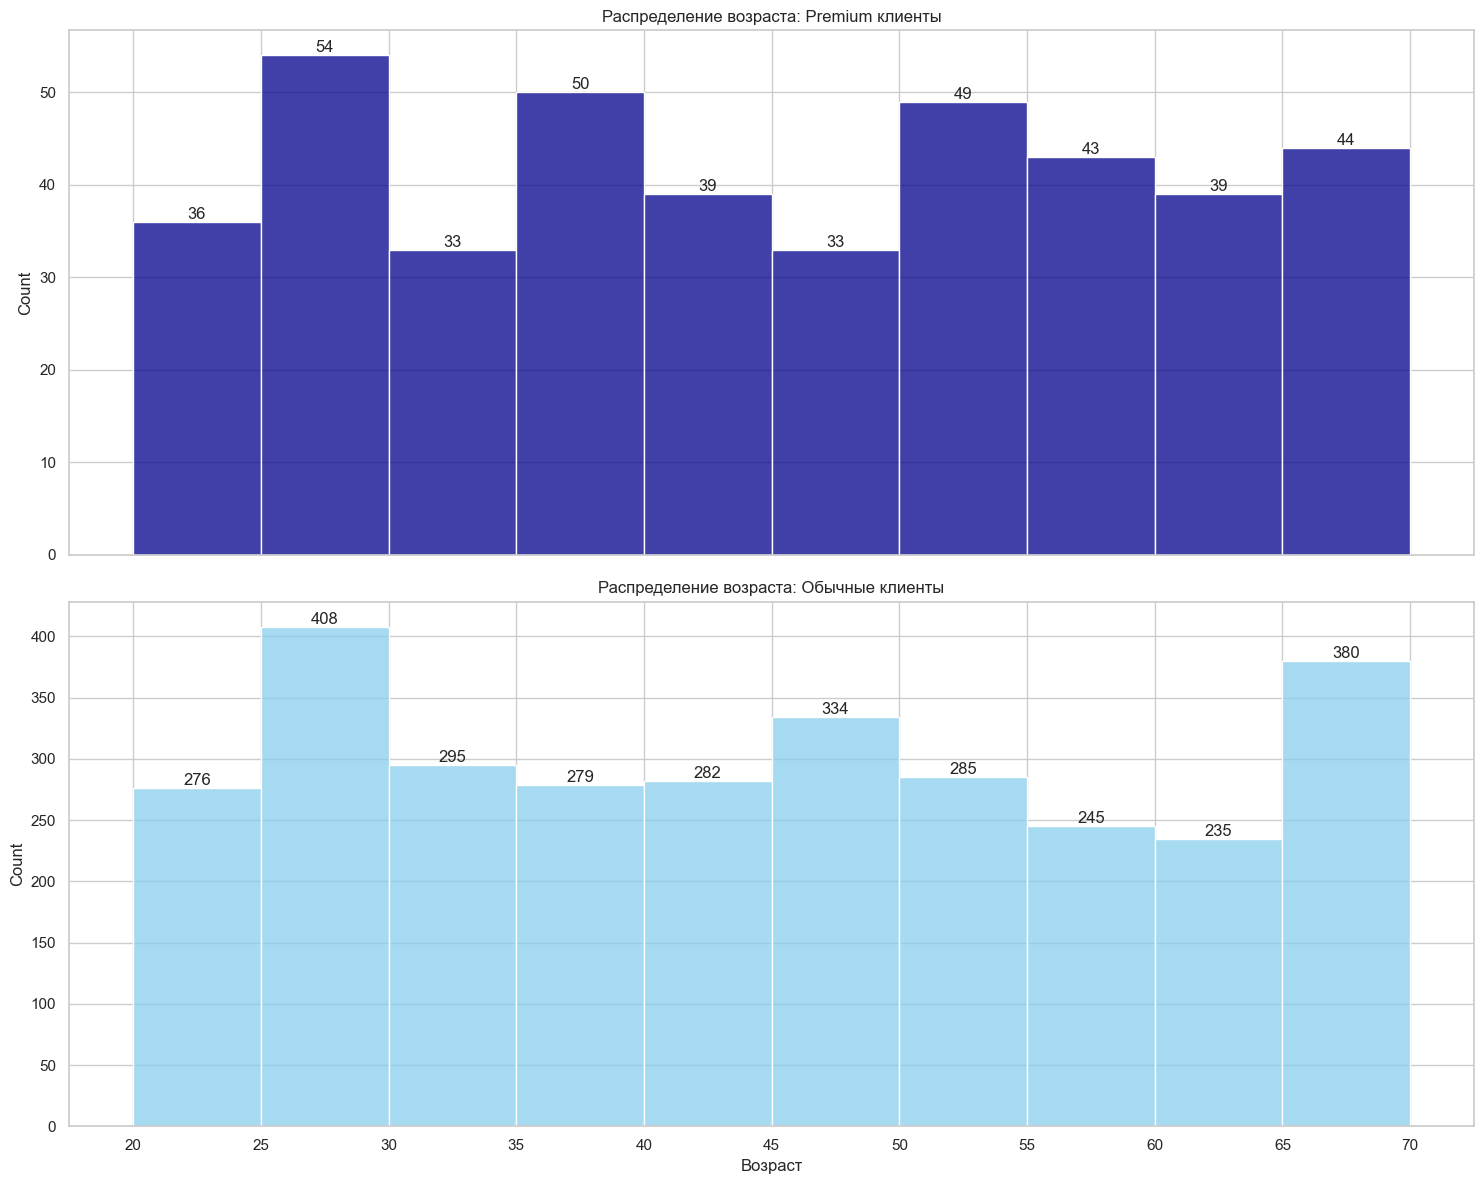

/var/folders/fy/hf0v9l_j1mn907s1ztzmwcp00000gp/T/ipykernel_78777/3704170037.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=win_rate, x='age_group', y='win_rate_percent', palette='viridis')


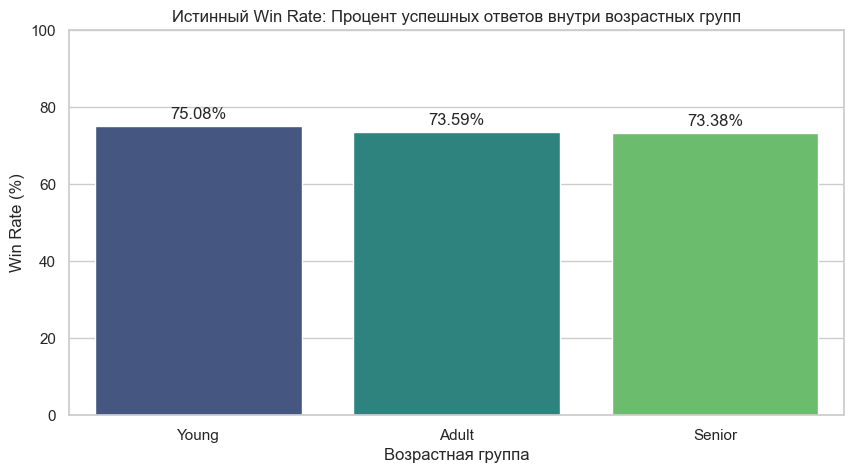

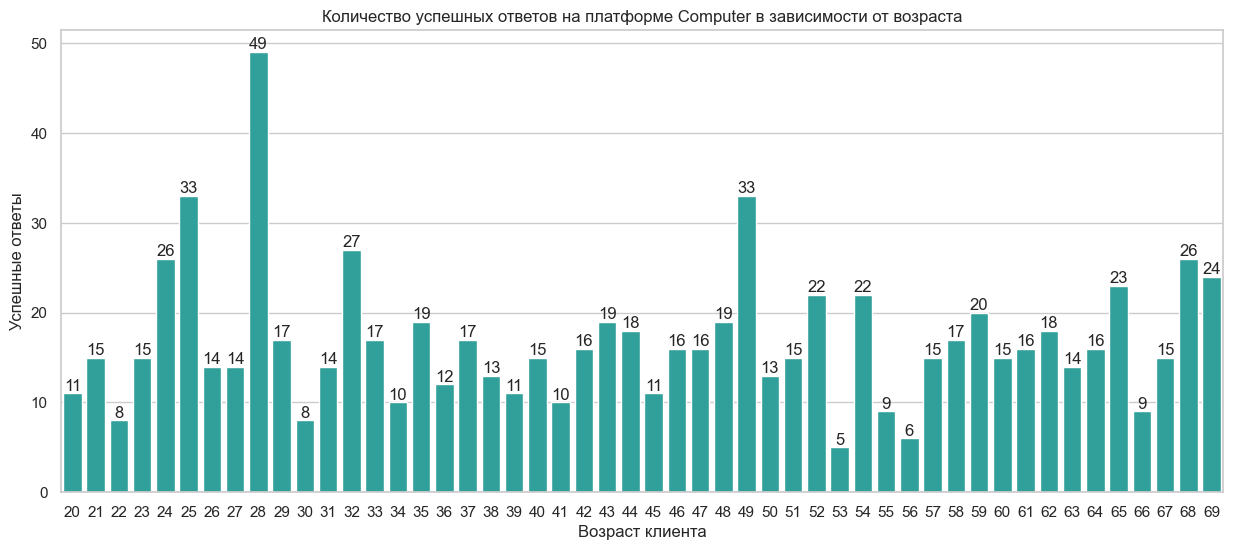

In [3]:
# ==========================================
# БЛОК 3: ДЕМОГРАФИЧЕСКИЙ АНАЛИЗ (ВОЗРАСТ)
# ==========================================
# 3.1 Сравнение распределения возраста (Premium vs Free)
fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
bins_range = np.arange(20, 75, 5)

sns.histplot(data=df_game.query('premium == True'), x='age', bins=bins_range, color='darkblue', ax=axes[0])
axes[0].bar_label(axes[0].containers[0])
axes[0].set_title('Распределение возраста: Premium клиенты')

sns.histplot(data=df_game.query('premium == False'), x='age', bins=bins_range, color='skyblue', ax=axes[1])
axes[1].bar_label(axes[1].containers[0])
axes[1].set_title('Распределение возраста: Обычные клиенты')
axes[1].set_xlabel('Возраст')

plt.xticks(bins_range)
plt.tight_layout()
plt.show()

# 3.2 Истинный Win Rate по возрастным группам (pd.cut)
df_game['age_group'] = pd.cut(df_game['age'], bins=3, labels=['Young', 'Adult', 'Senior'])

# Считаем среднее для success (доля True), чтобы получить честный процент успешных ответов
win_rate = round(df_game.groupby('age_group')['success'].mean() * 100, 2).reset_index()
win_rate = win_rate.rename(columns={'success': 'win_rate_percent'})

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=win_rate, x='age_group', y='win_rate_percent', palette='viridis')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.title('Истинный Win Rate: Процент успешных ответов внутри возрастных групп')
plt.xlabel('Возрастная группа')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 100) # ФИКСИРУЕМ ОСЬ ДО 100%, ТАК КАК ЭТО ПРОЦЕНТЫ
plt.show()

# 3.3 Успешные ответы на Computer по возрасту
computer_success_by_age = df_game.query('platform == "computer" and success == True') \
                                 .groupby('age').size().reset_index(name='success_count')

plt.figure(figsize=(15, 6))
ax = sns.barplot(data=computer_success_by_age, x='age', y='success_count', color='lightseagreen')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Количество успешных ответов на платформе Computer в зависимости от возраста')
plt.xlabel('Возраст клиента')
plt.ylabel('Успешные ответы')
plt.show()

/var/folders/fy/hf0v9l_j1mn907s1ztzmwcp00000gp/T/ipykernel_78777/3475589692.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=success_per_client, x='success_count', y='client_count', palette='plasma')


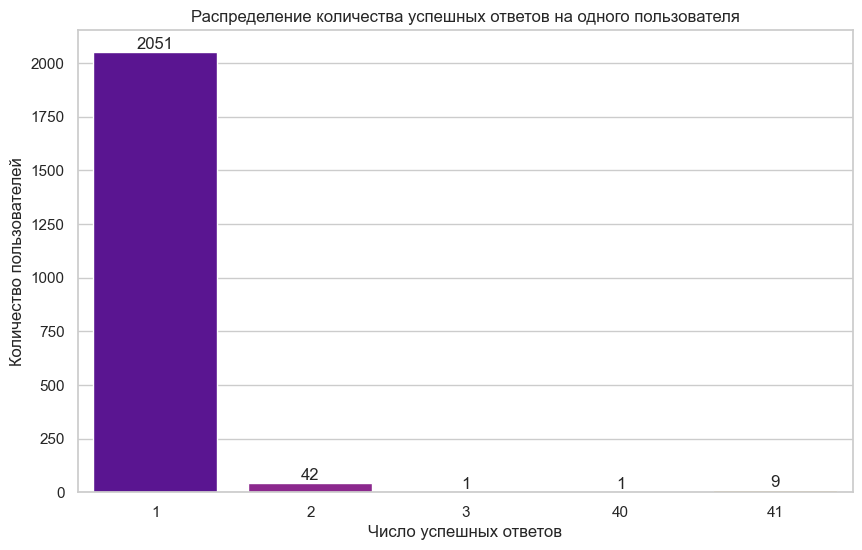

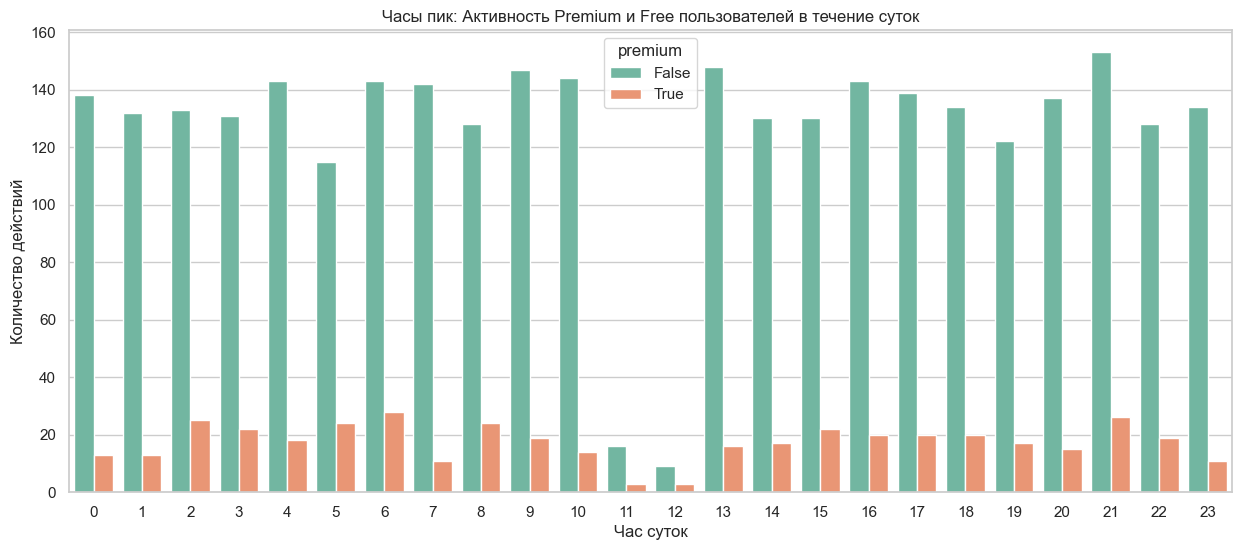

In [4]:
# ==========================================
# БЛОК 4: ВОВЛЕЧЕННОСТЬ И АНАЛИЗ АКТИВНОСТИ
# ==========================================
# 4.1 Распределение количества успешных ответов на одного пользователя
success_per_client = df_game.query('success == True').groupby('client').size().value_counts().reset_index()
success_per_client.columns = ['success_count', 'client_count']

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=success_per_client, x='success_count', y='client_count', palette='plasma')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Распределение количества успешных ответов на одного пользователя')
plt.xlabel('Число успешных ответов')
plt.ylabel('Количество пользователей')
plt.show()

# 4.2 Часы пик: Активность пользователей в течение суток
plt.figure(figsize=(15, 6))
ax = sns.countplot(data=df_game, x='hour', hue='premium', palette='Set2')
plt.title('Часы пик: Активность Premium и Free пользователей в течение суток')
plt.xlabel('Час суток')
plt.ylabel('Количество действий')
plt.show()


In [5]:
# ==========================================
# БЛОК 5: АНАЛИЗ "КИТОВ" (ТОП-5% АКТИВНЫХ ИГРОКОВ)
# ==========================================
# Считаем общее количество действий для каждого клиента
activity = df_game.groupby('client')['success'].count().reset_index(name='total_actions')

# Находим порог входа в Топ-5% (95-й перцентиль)
top_5_percent_threshold = activity['total_actions'].quantile(0.95)

# Фильтруем ID наших китов
whales_ids = activity.query('total_actions >= @top_5_percent_threshold')['client'].to_list()

# Собираем профиль китов: возраст, статус подписки и уникальные платформы
whales_profile = df_game.query('client.isin(@whales_ids)').groupby('client').agg({
    'success': 'count',       
    'age': 'first',           
    'premium': 'first',       
    'platform': 'unique'      # СОБИРАЕМ ВСЕ ПЛАТФОРМЫ, С КОТОРЫХ ИГРАЛ ЮЗЕР В ВИДЕ СПИСКА
}).rename(columns={'success': 'total_actions'}).sort_values('total_actions', ascending=False)

print(f"\nПорог входа в Топ-5%: {int(top_5_percent_threshold)} действий")
print(f"Количество найденных хардкорных игроков: {len(whales_ids)}")
print("\nПрофиль самых активных игроков:")
display(whales_profile.head(10)) # display() красиво выведет таблицу в Jupyter



Порог входа в Топ-5%: 1 действий
Количество найденных хардкорных игроков: 2954

Профиль самых активных игроков:


,total_actions,age,premium,platform
client,,,,
61468,42,25,False,"[phone, computer, tablet]"
61473,41,69,False,"[phone, computer, tablet]"
64064,41,49,False,"[computer, phone]"
78349,41,68,False,"[phone, computer, tablet]"
92584,41,28,False,"[phone, tablet, computer]"
36165,41,65,False,"[computer, phone, tablet]"
52870,41,24,False,"[computer, phone, tablet]"
12179,41,32,False,"[computer, phone, tablet]"
82563,41,28,False,"[computer, phone, tablet]"
